<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Measuring the Vanishing Gradient</b>
</h1>
<div style="font-family:'Times New Roman';">
Notebook 02 showed the LSTM failing at T=60 with the default forget bias. Here i measure the gradient itself instead of guessing from accuracy, so the reason is visible directly. This one needs no training at all, its just one backward pass.
</div>

## the experiment

feed a sequence of 60 steps, take the output at the **last** step, and ask how much each **input** step affected it. that is just `d(output)/d(x_t)` for every t.

if the gradient at t=0 is basicaly zero then the network cannot learn anything about the beginning of the sequence, no matter how long we train it.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

T, H = 60, 32
x0 = torch.randn(1, T, 1)

def input_gradients(core):
    x = x0.clone().requires_grad_(True)
    out, _ = core(x)
    out[:, -1].sum().backward()          # loss depends only on the last step
    return x.grad[0, :, 0].abs().detach()

three models, all untrained, just fresh weights:

- a plain RNN
- an LSTM the way pytorch gives it (forget bias 0)
- the same LSTM with the forget gate bias set to 3

In [2]:
rnn   = nn.RNN(1, H, batch_first=True)
lstm  = nn.LSTM(1, H, batch_first=True)
lstm3 = nn.LSTM(1, H, batch_first=True)

# pytorch packs the biases as [input, forget, cell, output], so the forget part is H : 2H
with torch.no_grad():
    for name, param in lstm3.named_parameters():
        if 'bias' in name:
            param[H:2*H].fill_(3.0)

g_rnn   = input_gradients(rnn)
g_lstm  = input_gradients(lstm)
g_lstm3 = input_gradients(lstm3)

print("gradient at the first step (t=0):")
print("  rnn                :", format(g_rnn[0].item(), '.2e'))
print("  lstm forget bias 0 :", format(g_lstm[0].item(), '.2e'))
print("  lstm forget bias 3 :", format(g_lstm3[0].item(), '.2e'))

gradient at the first step (t=0):
  rnn                : 5.73e-15
  lstm forget bias 0 : 2.68e-13
  lstm forget bias 3 : 1.31e-01


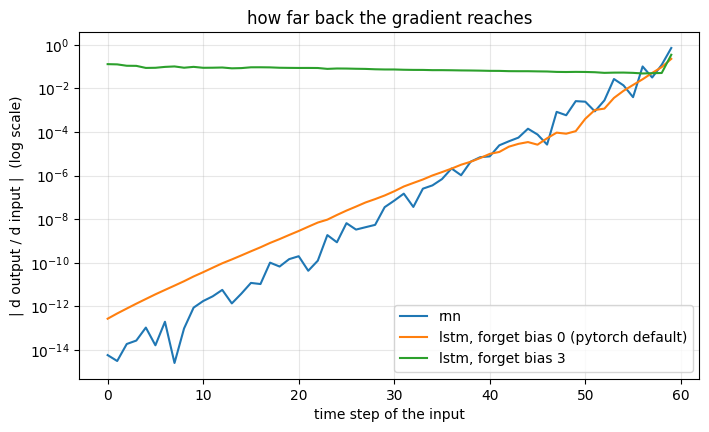

In [3]:
plt.figure(figsize=(8,4.5))
plt.semilogy(g_rnn,   label='rnn')
plt.semilogy(g_lstm,  label='lstm, forget bias 0 (pytorch default)')
plt.semilogy(g_lstm3, label='lstm, forget bias 3')
plt.xlabel('time step of the input'); plt.ylabel('| d output / d input |  (log scale)')
plt.legend(); plt.grid(alpha=.3)
plt.title('how far back the gradient reaches')
plt.show()

the y axis is log. the RNN line falls from around 1 at the last step down to 1e-15 at the first step, thats 15 orders of magnitude. anything that small is dead, the weights connected to the early steps will never move.

the default LSTM is a bit better but it is also falling off a cliff. only the one with the forget bias opened stays roughly flat across all 60 steps.

In [5]:
print("gradient at t=0 as a fraction of the gradient at t=59 :")
for name, g in [("rnn", g_rnn), ("lstm bias 0", g_lstm), ("lstm bias 3", g_lstm3)]:
    print("  ", name.ljust(12), format((g[0] / g[-1]).item(), '.2e'))

gradient at t=0 as a fraction of the gradient at t=59 :
   rnn          7.94e-15
   lstm bias 0  1.17e-12
   lstm bias 3  3.71e-01


so with the bias at 3 the first step still carries about a third of the signal of the last step. with the default it is 1e-12, and the plain RNN is 1e-15.

this is the same result as notebook 02 but measured directly instead of through accuracy.

## why, in one line each

- **rnn** : going back one step multiplies the gradient by `Wh` and by `(1 - h^2)` from the tanh. sixty steps means sixty multiplications by something smaller than 1
- **lstm** : the path along the cell state multiplies by the forget gate `f`. with f near 1 nothing shrinks, with f at 0.5 its 0.5^60

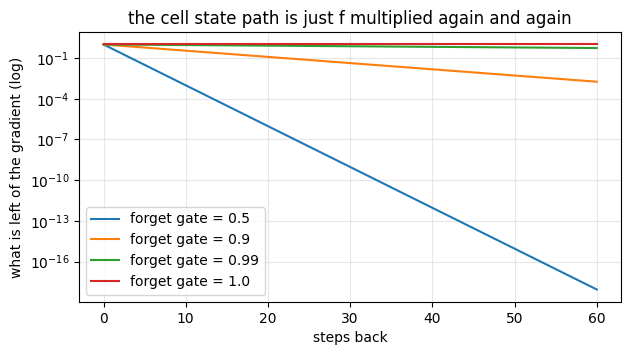

In [6]:
steps = torch.arange(61).float()
plt.figure(figsize=(7,3.5))
for f in [0.5, 0.9, 0.99, 1.0]:
    plt.semilogy(steps, f ** steps, label='forget gate = ' + str(f))
plt.xlabel('steps back'); plt.ylabel('what is left of the gradient (log)')
plt.legend(); plt.grid(alpha=.3)
plt.title('the cell state path is just f multiplied again and again')
plt.show()

## what a trained model does with its gates

training a small LSTM on the same memory task from notebook 02, then looking at what the forget gate actually settles to.

In [14]:
def make_data(n, T, noise=0.5, seed=0):
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, T, 1, generator=g) * noise
    bit = torch.randint(0, 2, (n,), generator=g)
    x[:, 0, 0] = bit.float() * 2 - 1
    return x, bit

T2 = 30
x, y   = make_data(600, T2, seed=1)
xt, yt = make_data(300, T2, seed=2)

core = nn.LSTM(1, 16, batch_first=True)
head = nn.Linear(16, 2)
with torch.no_grad():
    for name, param in core.named_parameters():
        if 'bias' in name:
            param[16:32].fill_(1.0)          # open the forget gate at the start

params = list(core.parameters()) + list(head.parameters())
opt = torch.optim.Adam(params, lr=0.02)
loss_fn = nn.CrossEntropyLoss()

for ep in range(300):
    out, _ = core(x)
    loss = loss_fn(head(out[:, -1]), y)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(params, 2.0)
    opt.step()

with torch.no_grad():
    o, _ = core(xt)
    acc = (head(o[:, -1]).argmax(1) == yt).float().mean().item()
print("accuracy after training :", round(acc * 100, 1), "%")

accuracy after training : 100.0 %


now pulling the forget gate values out of the trained model, one number per hidden unit per time step.

In [9]:
W_ih, W_hh = core.weight_ih_l0, core.weight_hh_l0
b_ih, b_hh = core.bias_ih_l0, core.bias_hh_l0

h = torch.zeros(1, 16)
cell = torch.zeros(1, 16)
forget_track = []

with torch.no_grad():
    for t in range(T2):
        z = xt[:1, t] @ W_ih.T + h @ W_hh.T + b_ih + b_hh
        i, f, g, o = z.chunk(4, dim=1)
        i, f, g, o = torch.sigmoid(i), torch.sigmoid(f), torch.tanh(g), torch.sigmoid(o)
        cell = f * cell + i * g
        h = o * torch.tanh(cell)
        forget_track.append(f[0].clone())

forget_track = torch.stack(forget_track).numpy()
print("forget gate values, shape :", forget_track.shape, "(time steps, hidden units)")
print("average forget gate :", round(float(forget_track.mean()), 3))

forget gate values, shape : (30, 16) (time steps, hidden units)
average forget gate : 0.911


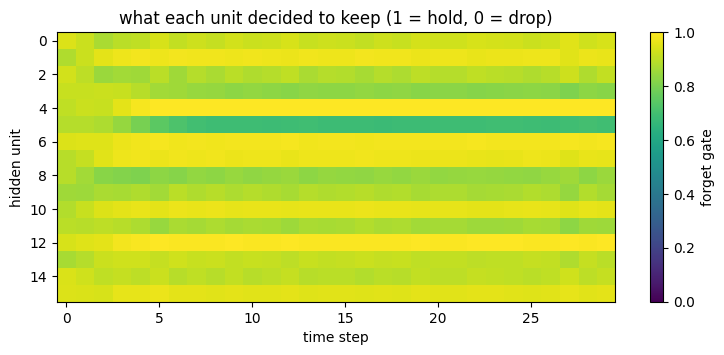

In [10]:
plt.figure(figsize=(9,3.5))
plt.imshow(forget_track.T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='forget gate')
plt.xlabel('time step'); plt.ylabel('hidden unit')
plt.title('what each unit decided to keep (1 = hold, 0 = drop)')
plt.show()

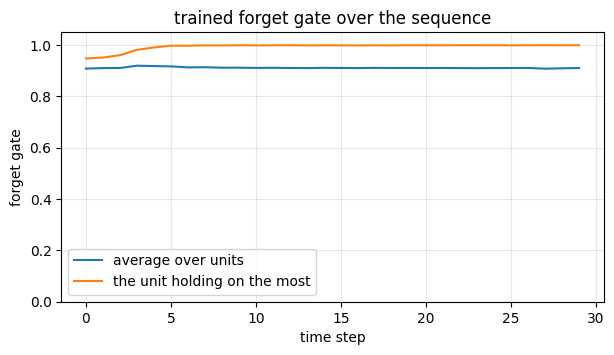

In [12]:
plt.figure(figsize=(7,3.5))
plt.plot(forget_track.mean(axis=1), label='average over units')
plt.plot(forget_track.max(axis=1), label='the unit holding on the most')
plt.ylim(0,1.05); plt.xlabel('time step'); plt.ylabel('forget gate')
plt.legend(); plt.grid(alpha=.3)
plt.title('trained forget gate over the sequence')
plt.show()

almost every unit ends up holding its gate high, mostly between 0.8 and 1, average 0.911. the lowest one sits around 0.6, nothing goes near 0.

that actually fits this task. the only thing worth remembering is the value at step 0 and there are no distractors that need to be thrown away, so there is nothing for the network to forget. on a task like language, where old context does become useless, the gates would drop much lower in places.

the first 2 or 3 steps are visibly lower than the rest, that is the model writing the bit in before it settles into hold mode.

### recap

| | gradient reaching t=0 |
|---|---|
| rnn | 1e-15 of the last step |
| lstm, forget bias 0 | 1e-12 |
| lstm, forget bias 3 | 0.37 |

- the vanishing gradient is measurable in one backward pass, no training needed
- the LSTM advantage comes from the forget gate being open, not from the gates existing
- after training the gates settle near 1 on this task, wich is exactly the hold behaviour it needed
- practical takeaway, set the forget bias to 1 when using nn.LSTM, pytorch leaves it at 0